In [1]:
import os
#os.environ["KAGGLE_API_TOKEN"]="xxxxxx"
#KAGGLE_API_TOKEN=xxxxxxx
#! bash export KAGGLE_API_TOKEN=xxxxxx

In [2]:
iload=0

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
!cd C:\Users\Cyril\Documents\python\jedha\M11_projet\explo\music_genre_classification

Le chemin d'acc�s sp�cifi� est introuvable.


In [5]:
!echo $env:KAGGLE_API_TOKEN

$env:KAGGLE_API_TOKEN


In [6]:
!cd ..

In [7]:
if iload:
    !kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification

In [8]:
if iload:
    import kagglehub
    import kagglesdk

    # Download latest version
    path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

    print("Path to dataset files:", path)

# EDA of data 

main parts of this notebook are inspired from:
    https://www.kaggle.com/code/andradaolteanu/work-w-audio-data-visualise-classify-recommend/notebook

In [9]:
# Usual Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn

# Librosa (the mother of audio files)
import librosa
import librosa.display
import IPython.display as ipd
import warnings
warnings.filterwarnings('ignore')

In [10]:
import os
os.getcwd()

'c:\\Users\\Cyril\\Documents\\python\\jedha\\M11_projet\\music_genre_classification\\GTZAN_music_genre_classification\\EDA_CNN'

### locate your data 

update `general_path` to where your data are located relatively to this notebook

In [11]:
import os
# Cyril data located 2 steps above :
general_path = '../../gtzan-dataset-music-genre-classification/Data'
print(list(os.listdir(f'{general_path}/genres_original/')))

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## Explore Audio Data

We will use librosa, which is the mother of audio files.
Understanding Audio

Let's first Explore our Audio Data to see how it looks (we'll work with reggae.00036.wav file).

    Sound: sequence of vibrations in varying pressure strengths (y)
    The sample rate (sr) is the number of samples of audio carried per second, measured in Hz or kHz


In [12]:
# Importing 1 file
genre = "rock"
audio_file_name = f"{genre}.00053"
y, sr = librosa.load(f"{general_path}/genres_original/{genre}/{audio_file_name}.wav")

print('y:', y, '\n')
print('y shape:', np.shape(y)[0], '\n')
print('Sample Rate (KHz):', sr, '\n')

# Verify length of the audio
print(f"Check Len of Audio: {np.shape(y)[0]/sr:2.2f} s")

y: [ 0.16378784  0.19824219  0.1796875  ... -0.23965454  0.03549194
  0.32717896] 

y shape: 661794 

Sample Rate (KHz): 22050 

Check Len of Audio: 30.01 s


In [13]:
2**10

1024

In [14]:
2**14

16384

In [15]:
# Trim leading and trailing silence from an audio signal (silence before and after the actual audio)
audio_file, _ = librosa.effects.trim(y)

# the result is an numpy ndarray
print('Audio File:', audio_file, '\n')
print('Audio File shape:', np.shape(audio_file))

Audio File: [ 0.16378784  0.19824219  0.1796875  ... -0.23965454  0.03549194
  0.32717896] 

Audio File shape: (661794,)


## 2D Representation: Sound Waves

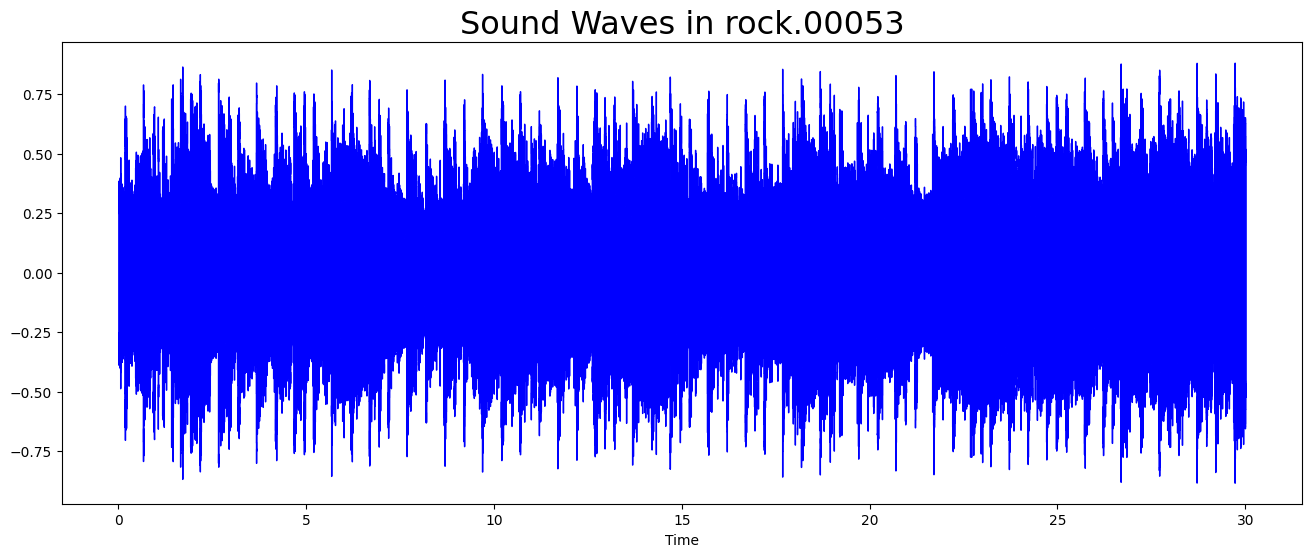

In [16]:
plt.figure(figsize = (16, 6))
#librosa.display.waveshow(y = audio_file, sr = sr, color = "#A300F9");
librosa.display.waveshow(y = audio_file, sr = sr, color = "blue")
plt.title(f"Sound Waves in {audio_file_name}", fontsize = 23);

# Fourier Transform¶

    Function that gets a signal in the time domain as input, and outputs its decomposition into frequencies
    Transform both the y-axis (frequency) to log scale, and the “color” axis (amplitude) to Decibels, which is approx. the log scale of amplitudes.


In [17]:
# Importing 1 file
genre = "reggae"
audio_file_name = "reggae.00039"
y, sr = librosa.load(f"{general_path}/genres_original/{genre}/{audio_file_name}.wav")
genre = "rock"
audio_file_name = f"{genre}.00053"
y, sr = librosa.load(f"{general_path}/genres_original/{genre}/{audio_file_name}.wav")

audio_file, _ = librosa.effects.trim(y)

# Default FFT window size
# on a nfft/2 frequences entre 0 et 22000/2 Hz : Df = 220000/2048 
n_fft = 2048 # FFT window size
hop_length = 512 # number audio of frames between STFT columns (looks like a good default)


# Short-time Fourier transform (STFT)
D = np.abs(librosa.stft(audio_file, n_fft = n_fft, hop_length = hop_length))

print('Shape of D object:', np.shape(D))

Shape of D object: (1025, 1293)


In [18]:
Df = sr/n_fft
print(f"spectral definition: {Df} Hz")
# time step of spectra : 
# length of spectra 
ls = n_fft/sr
print(f"duration of each spectra : {ls} s")

ts = 512/sr
print(f"time step spectra : {ts} s")
#nb pixel in x : 
npx_x = 30/ts
print(f"nb pix in x {npx_x} ")

spectral definition: 10.7666015625 Hz
duration of each spectra : 0.09287981859410431 s
time step spectra : 0.023219954648526078 s
nb pix in x 1291.9921875 


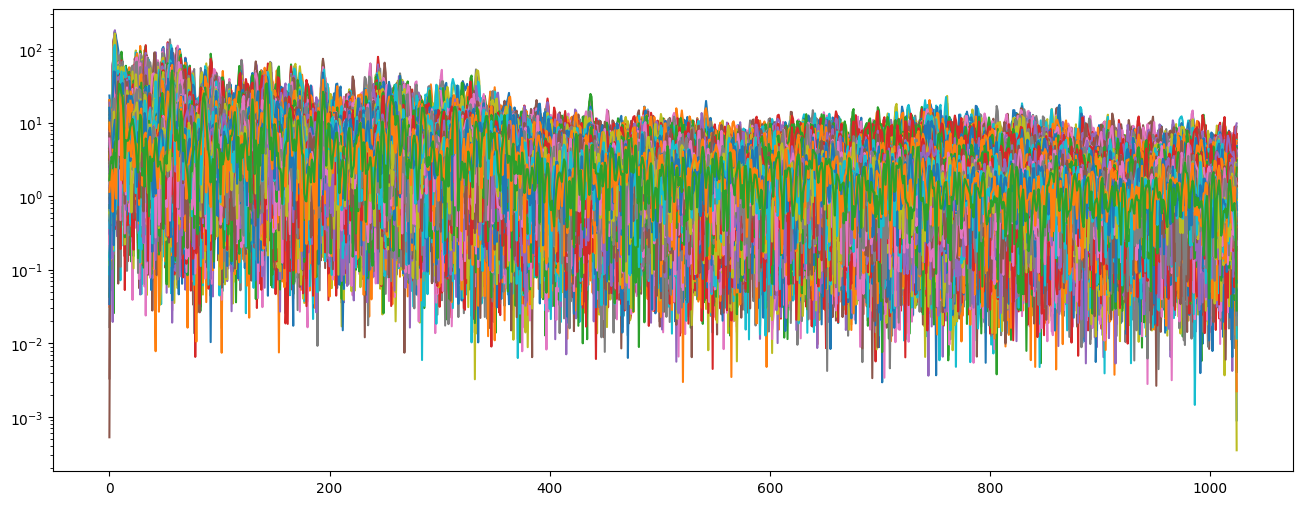

In [19]:
plt.figure(figsize = (16, 6))
plt.semilogy(D);

# The Spectrogram¶

    What is a spectrogram? A spectrogram is a visual representation of the spectrum of frequencies of a signal as it varies with time. When applied to an audio signal, spectrograms are sometimes called sonographs, voiceprints, or voicegrams (wiki).
    Here we convert the frequency axis to a logarithmic one.


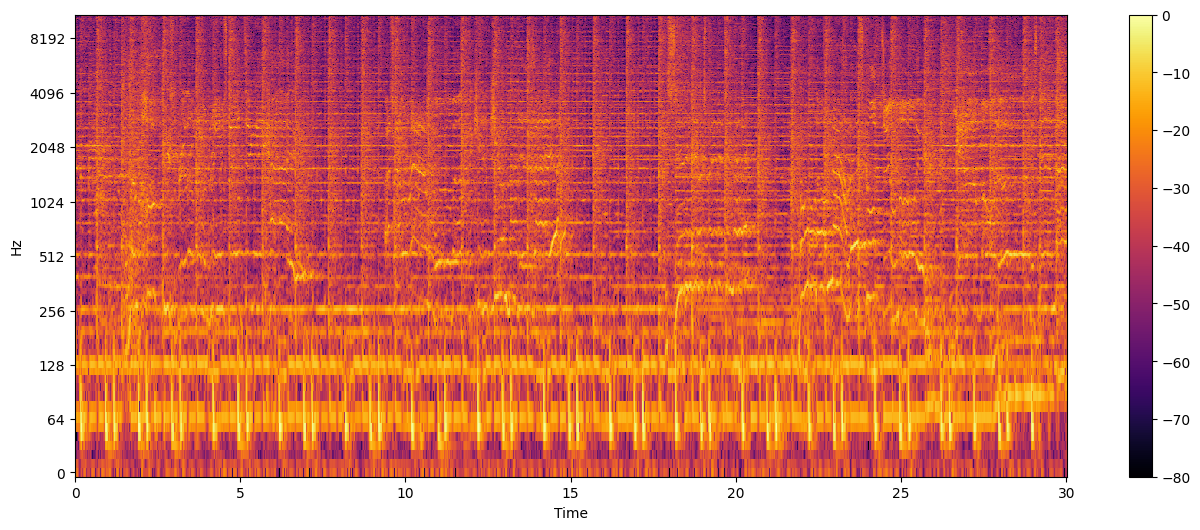

In [ ]:
# Convert an amplitude spectrogram to Decibels-scaled spectrogram.
DB = librosa.amplitude_to_db(D, ref = np.max)
#dB = 20 * Log10(amplitude/P0)   P0 = 20 .10^-6 Pa 
# Creating the Spectogram
plt.figure(figsize = (16, 6))
# librosa.display.specshow(DB, sr = sr, hop_length = hop_length, x_axis = 'time', y_axis = 'log',
#                         cmap = 'cool')
librosa.display.specshow(DB, sr = sr, hop_length = hop_length, x_axis = 'time', y_axis = 'log',
                        cmap = 'inferno')
plt.colorbar();

## Mel Spectrogram

    The Mel Scale, mathematically speaking, is the result of some non-linear transformation of the frequency scale. The Mel Spectrogram is a normal Spectrogram, but with a Mel Scale on the y axis.


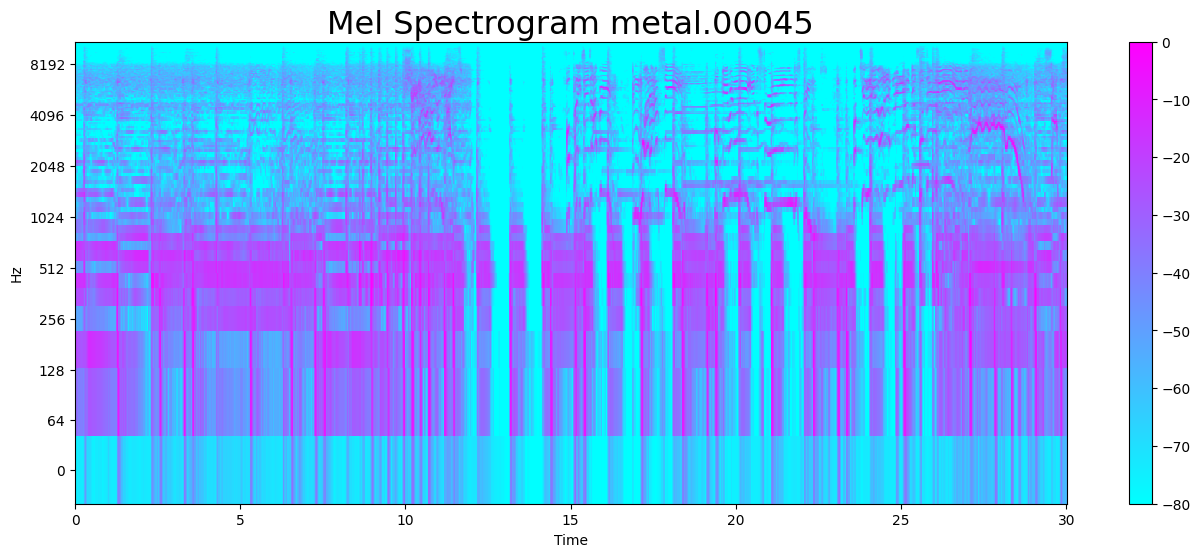

In [21]:
genre = "metal"
audio_file_name = f"{genre}.00045"
y, sr = librosa.load(f"{general_path}/genres_original/{genre}/{audio_file_name}.wav")
y, _ = librosa.effects.trim(y)


S = librosa.feature.melspectrogram(y=y, sr=sr)
S_DB = librosa.amplitude_to_db(S, ref=np.max)
plt.figure(figsize = (16, 6))
librosa.display.specshow(S_DB, sr=sr, hop_length=hop_length, x_axis = 'time', y_axis = 'log',
                        cmap = 'cool');
plt.colorbar();
plt.title(f"Mel Spectrogram {audio_file_name}", fontsize = 23);

In [22]:
S

array([[9.51445699e-01, 2.10453540e-01, 4.60510962e-02, ...,
        3.66966546e-01, 2.41513833e-01, 3.87480795e-01],
       [4.30329561e+00, 4.98595428e+00, 4.10185289e+00, ...,
        2.06992364e+00, 1.50762010e+00, 1.15401995e+00],
       [6.53913164e+00, 1.56490059e+01, 1.70805550e+01, ...,
        2.09004498e+01, 2.20505161e+01, 1.19070988e+01],
       ...,
       [4.58695149e-06, 1.51024642e-06, 3.64006382e-07, ...,
        1.08223230e-06, 1.41949602e-06, 1.23863638e-05],
       [4.17379124e-06, 1.04141600e-06, 2.60537050e-08, ...,
        8.69772805e-08, 3.51090108e-07, 1.16973715e-05],
       [3.92769562e-06, 9.70136171e-07, 4.07692635e-09, ...,
        8.55003712e-09, 2.20869495e-07, 1.13755277e-05]],
      shape=(128, 1293), dtype=float32)

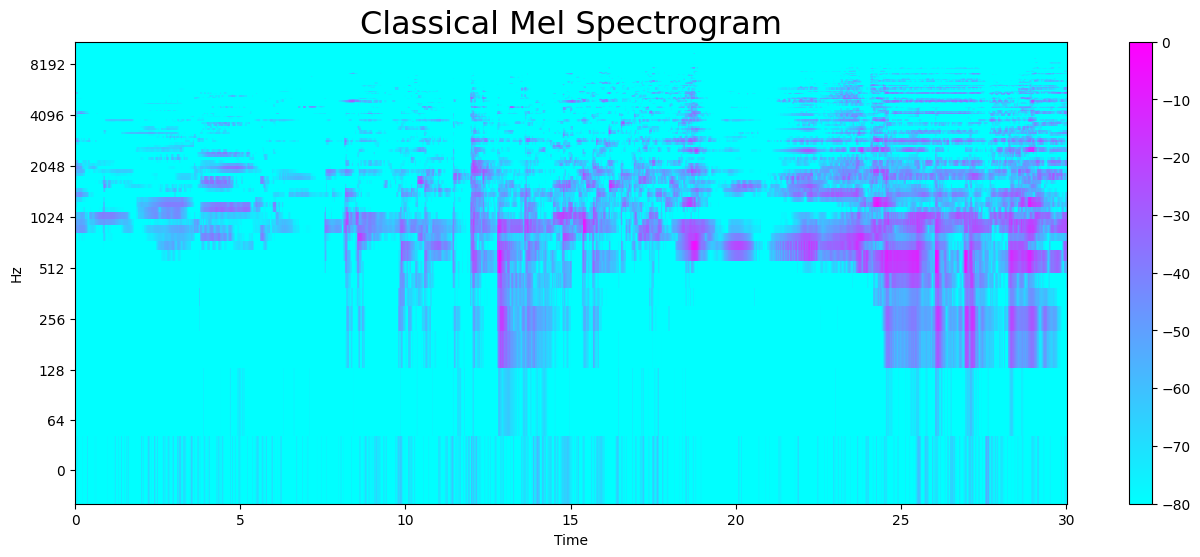

In [23]:
genre = "classical"
audio_file_name = f"{genre}.00038"
y, sr = librosa.load(f"{general_path}/genres_original/{genre}/{audio_file_name}.wav")
#y, sr = librosa.load(f'{general_path}/genres_original/classical/classical.00036.wav')
audio_file, _ = librosa.effects.trim(y)
y, _ = librosa.effects.trim(y)


S = librosa.feature.melspectrogram(y=y, sr=sr)
S_DB = librosa.amplitude_to_db(S, ref=np.max)
plt.figure(figsize = (16, 6))
librosa.display.specshow(S_DB, sr=sr, hop_length=hop_length, x_axis = 'time', y_axis = 'log',
                        cmap = 'cool');
plt.colorbar();
plt.title("Classical Mel Spectrogram", fontsize = 23);

### Audio Features

#### First of all : load Features matrix to validate

In [24]:
data = pd.read_csv(f'{general_path}/features_30_sec.csv')
data.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [25]:
features = data[data['filename']==f"{audio_file_name}.wav"]
features

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
138,classical.00038.wav,661794,0.294419,0.088058,0.044348,0.001093,1279.275979,92135.031718,1339.297621,49909.17871,...,50.893707,-2.238529,59.249638,-3.53203,51.606426,-2.99442,89.383568,-3.297078,97.686836,classical


In [26]:
## test append features 
features = []
column_names = []
chroma = librosa.feature.chroma_stft(y=y, sr=sr)
feature = chroma
features.extend([feature.mean(),feature.var()])
column_names.extend(['chroma_mean','chroma_var'])

In [27]:
feat2 = []
feat2_cols=[]
mfccs2   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
mfccs2
for idx,x in enumerate(mfccs2):
    feat2.extend([np.mean(x),np.var(x)])
    feat2_cols.extend([f"mfcc{idx+1}_mean",f"mfcc{idx+1}_var"])

feat2_cols

df_features = pd.DataFrame(columns=feat2_cols)
df_features.loc[0] = feat2
df_features

,mfcc1_mean,mfcc1_var,mfcc2_mean,mfcc2_var,mfcc3_mean,mfcc3_var,mfcc4_mean,mfcc4_var,mfcc5_mean,mfcc5_var,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
0,-275.967804,6583.662598,146.325363,487.643127,-36.601395,376.773651,24.209837,257.865997,-2.551709,165.227417,...,-1.766936,50.951782,-2.253068,59.056984,-3.546489,51.423615,-2.992175,89.271683,-3.2847,97.682816


In [28]:
features = df_features.loc[0]
features

mfcc1_mean     -275.967804
mfcc1_var      6583.662598
mfcc2_mean      146.325363
mfcc2_var       487.643127
mfcc3_mean      -36.601395
mfcc3_var       376.773651
mfcc4_mean       24.209837
mfcc4_var       257.865997
mfcc5_mean       -2.551709
mfcc5_var       165.227417
mfcc6_mean       -2.155176
mfcc6_var        89.060638
mfcc7_mean      -13.308850
mfcc7_var        94.711555
mfcc8_mean       -6.500922
mfcc8_var        79.426933
mfcc9_mean       -9.406593
mfcc9_var        72.235352
mfcc10_mean      -3.121519
mfcc10_var       60.509476
mfcc11_mean     -11.546325
mfcc11_var       66.878296
mfcc12_mean      -4.189929
mfcc12_var       62.880775
mfcc13_mean      -1.699939
mfcc13_var      108.371254
mfcc14_mean      -1.538669
mfcc14_var       69.974777
mfcc15_mean      -3.208078
mfcc15_var       72.269409
mfcc16_mean      -1.766936
mfcc16_var       50.951782
mfcc17_mean      -2.253068
mfcc17_var       59.056984
mfcc18_mean      -3.546489
mfcc18_var       51.423615
mfcc19_mean      -2.992175
m

In [29]:
mfccs   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)



Zero Crossing Rate

    the rate at which the signal changes from positive to negative or back.


In [30]:
# Total zero_crossings in our 1 song
zero_crossings = librosa.zero_crossings(audio_file, pad=False)
zero_crossing_rate_mean = zero_crossings.mean()
zero_crossing_rate_var = np.var(zero_crossings)

print(zero_crossing_rate_mean,features['zero_crossing_rate_mean'])
print(zero_crossing_rate_var,features['zero_crossing_rate_var'])
features['zero_crossing_rate_mean']

KeyError: 'zero_crossing_rate_mean'

### Harmonics and Perceptrual¶

    Harmonics are characteristichs that human years can't distinguish (represents the sound color)
    Perceptrual understanding shock wave represents the sound rhythm and emotion


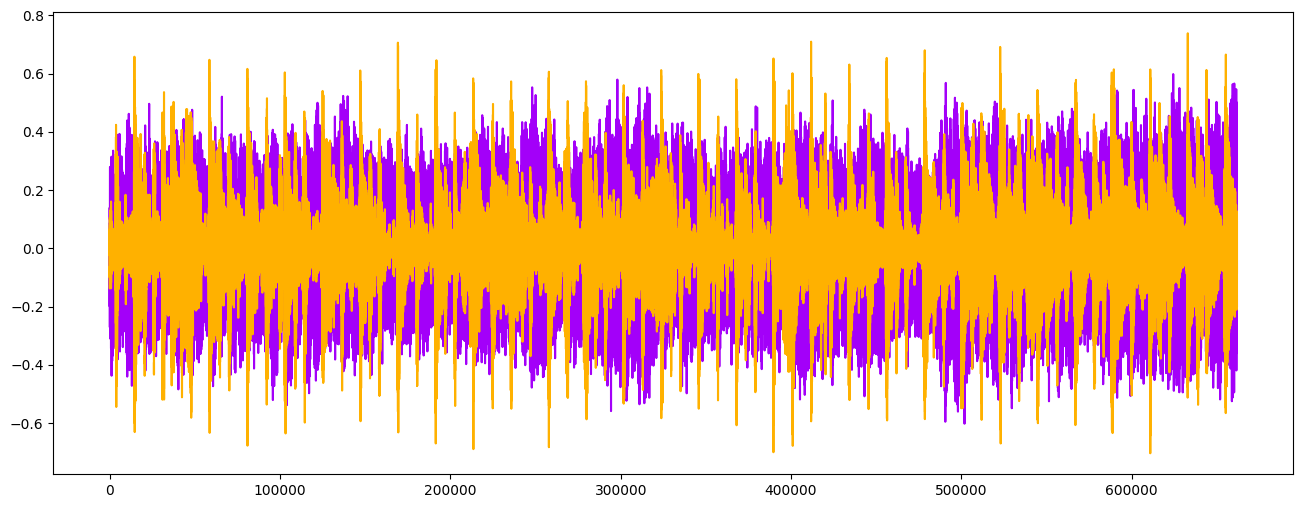

In [ ]:
y_harm, y_perc = librosa.effects.hpss(audio_file)
harmony_mean = y_harm.mean()
harmony_var = y_harm.var()
perceptr_mean = y_perc.mean()
perceptr_var = y_perc.var()

plt.figure(figsize = (16, 6))
plt.plot(y_harm, color = '#A300F9');
plt.plot(y_perc, color = '#FFB100');

### Tempo BMP (beats per minute)

Dynamic programming beat tracker.

In [ ]:
tempo, _ = librosa.beat.beat_track(y=y, sr = sr)
tempo

array([151.99908088])

### Spectral Centroid

    indicates where the ”centre of mass” for a sound is located and is calculated as the weighted mean of the frequencies present in the sound.


In [ ]:
# Calculate the Spectral Centroids
spectral_centroids = librosa.feature.spectral_centroid(y=audio_file, sr=sr)[0]

# Shape is a vector
print('Centroids:', spectral_centroids, '\n')
print('Shape of Spectral Centroids:', spectral_centroids.shape, '\n')

# Computing the time variable for visualization
frames = range(len(spectral_centroids))

# Converts frame counts to time (seconds)
t = librosa.frames_to_time(frames)

print('frames:', frames, '\n')
print('t:', t)

# Function that normalizes the Sound Data
def normalize(x, axis=0):
    return sklearn.preprocessing.minmax_scale(x, axis=axis)

Centroids: [3037.45858659 3223.20618571 3281.95906478 ... 3496.51161884 3504.84742996
 3346.45229886] 

Shape of Spectral Centroids: (1293,) 

frames: range(0, 1293) 

t: [0.00000000e+00 2.32199546e-02 4.64399093e-02 ... 2.99537415e+01
 2.99769615e+01 3.00001814e+01]


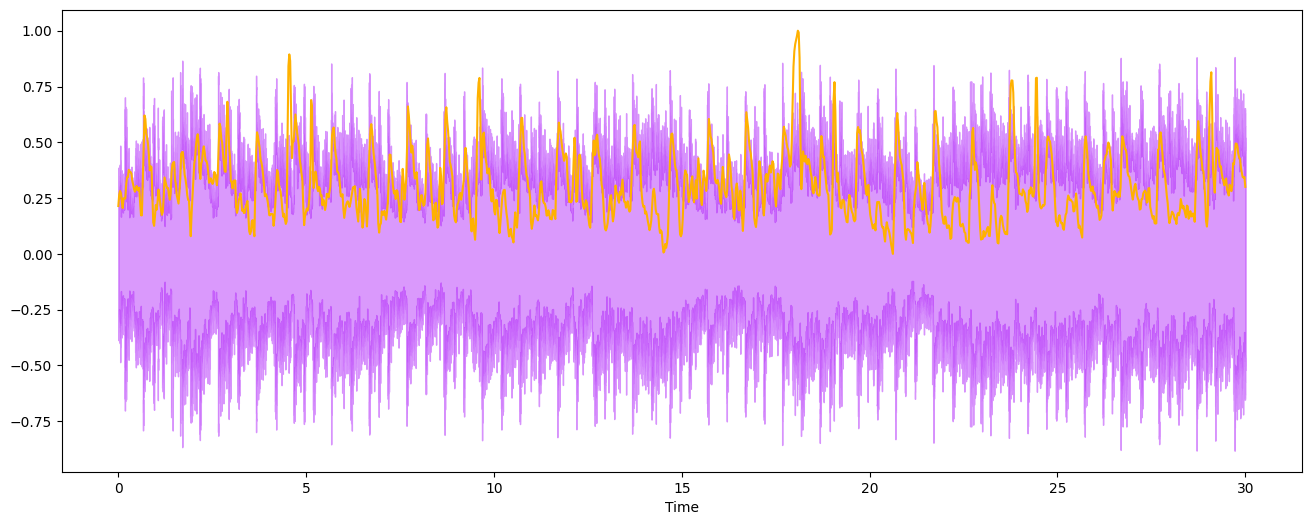

In [ ]:
#Plotting the Spectral Centroid along the waveform
plt.figure(figsize = (16, 6))
librosa.display.waveshow(y=audio_file, sr=sr, alpha=0.4, color = '#A300F9');
plt.plot(t, normalize(spectral_centroids), color='#FFB100');

### Spectral Rolloff

    is a measure of the shape of the signal. It represents the frequency below which a specified percentage of the total spectral energy, e.g. 85%, lies


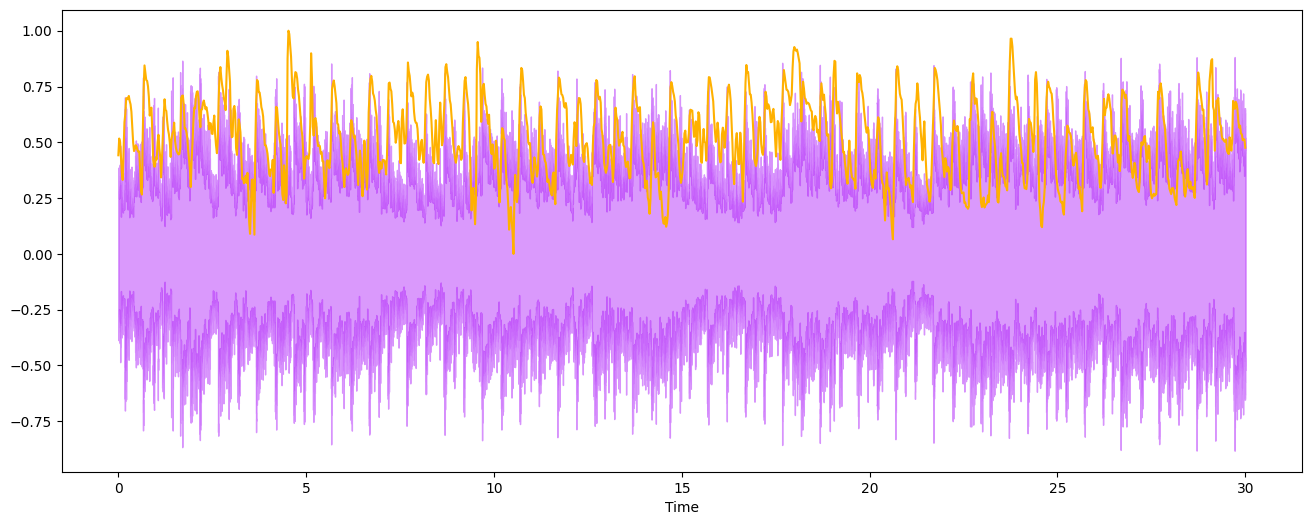

In [ ]:
# Spectral RollOff Vector
spectral_rolloff = librosa.feature.spectral_rolloff(y=audio_file, sr=sr)[0]

# The plot
plt.figure(figsize = (16, 6))
librosa.display.waveshow(audio_file, sr=sr, alpha=0.4, color = '#A300F9');
plt.plot(t, normalize(spectral_rolloff), color='#FFB100');

### Mel-Frequency Cepstral Coefficients:

    The Mel frequency cepstral coefficients (MFCCs) of a signal are a small set of features (usually about 10–20) which concisely describe the overall shape of a spectral envelope. It models the characteristics of the human voice.


mfccs shape: (20, 1293)


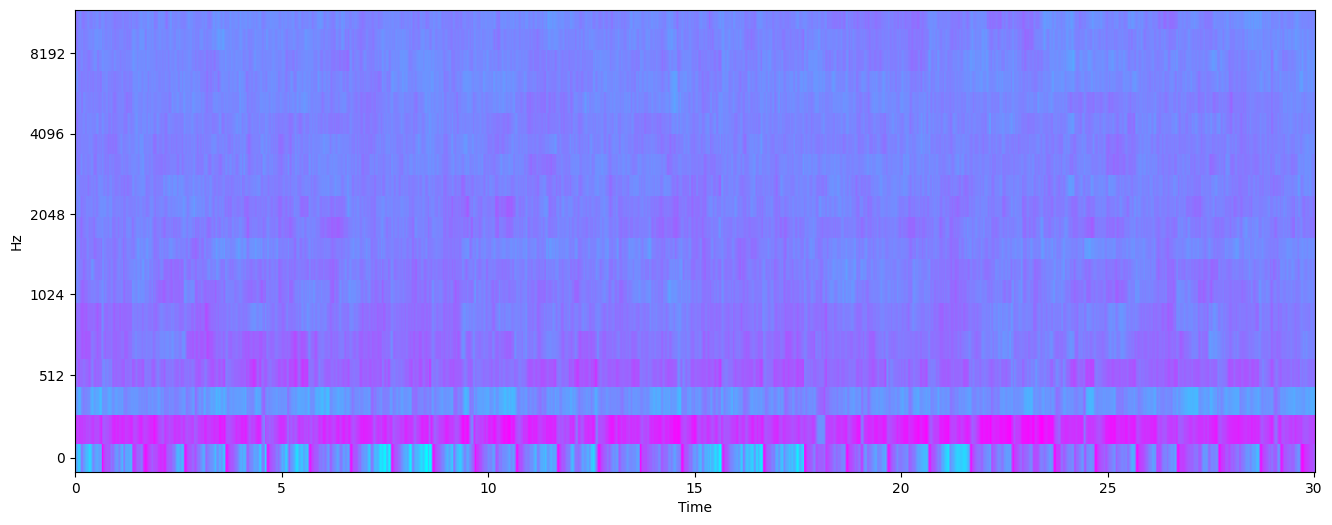

In [ ]:
mfccs = librosa.feature.mfcc(y=audio_file, sr=sr)
print('mfccs shape:', mfccs.shape)

#Displaying  the MFCCs:
plt.figure(figsize = (16, 6))
librosa.display.specshow(mfccs, sr=sr, x_axis='time', y_axis='mel', cmap = 'cool');

Mean: 1.9176745e-09 

Var: 1.0


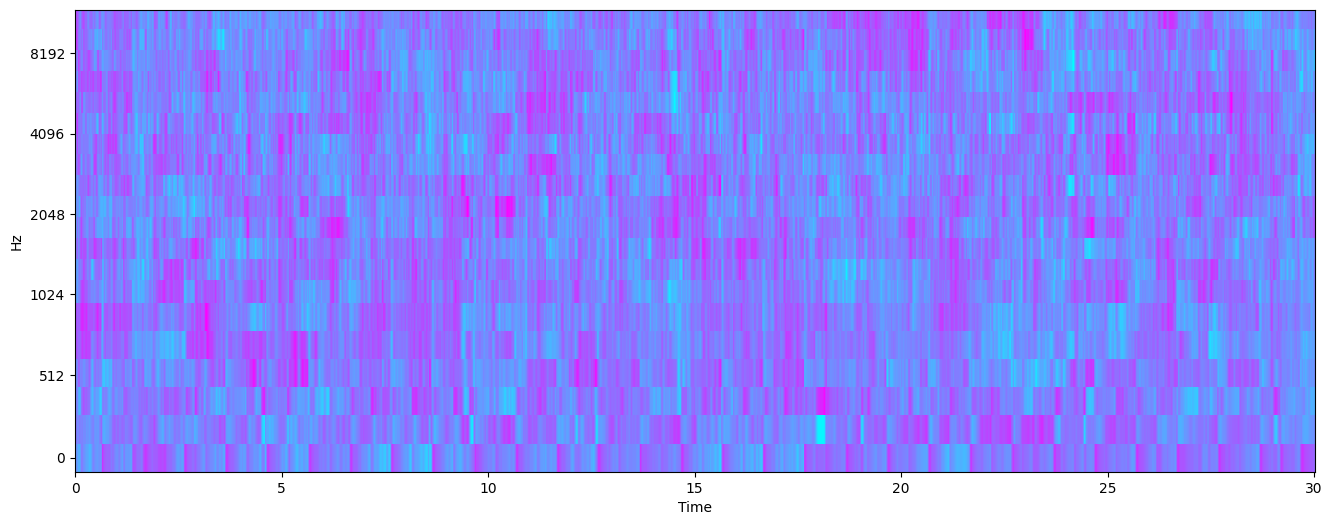

In [ ]:
# Perform Feature Scaling
mfccs = sklearn.preprocessing.scale(mfccs, axis=1)
print('Mean:', mfccs.mean(), '\n')
print('Var:', mfccs.var())

plt.figure(figsize = (16, 6))
librosa.display.specshow(mfccs, sr=sr, x_axis='time', y_axis='mel', cmap = 'cool');

### Chroma Frequencies

    Chroma features are an interesting and powerful representation for music audio in which the entire spectrum is projected onto 12 bins representing the 12 distinct semitones (or chroma) of the musical octave.


Chromogram shape: (12, 133)


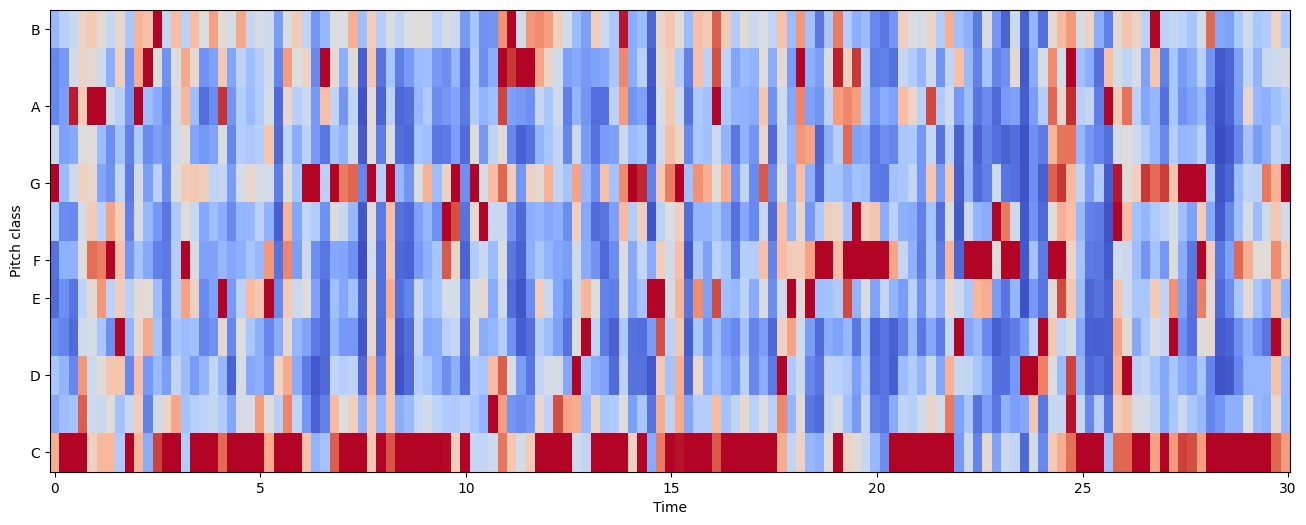

In [ ]:
# Increase or decrease hop_length to change how granular you want your data to be
hop_length = 5000

# Chromogram
chromagram = librosa.feature.chroma_stft(y=audio_file, sr=sr, hop_length=hop_length)
print('Chromogram shape:', chromagram.shape)

plt.figure(figsize=(16, 6))
librosa.display.specshow(chromagram, x_axis='time', y_axis='chroma', hop_length=hop_length, cmap='coolwarm');

## EDA

EDA is going to be performed on the features_30_sec.csv. This file contains the mean and variance for each audio file fo the features analysed above.

So, the table has a final of 1000 rows (10 genrex x 100 audio files) and 60 features (dimensionalities).

In [ ]:
data = pd.read_csv(f'{general_path}/features_30_sec.csv')
data.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [ ]:
data.columns

Index(['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean',
       'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var',
       'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean',
       'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var',
       'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo',
       'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean',
       'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var',
       'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean',
       'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',
       'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean',
       'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var',
       'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean',
       'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var',
  

#### Correlation Heatmap for feature means

In [ ]:
data.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [ ]:
data['filename']

0      blues.00000.wav
1      blues.00001.wav
2      blues.00002.wav
3      blues.00003.wav
4      blues.00004.wav
            ...       
995     rock.00095.wav
996     rock.00096.wav
997     rock.00097.wav
998     rock.00098.wav
999     rock.00099.wav
Name: filename, Length: 1000, dtype: object

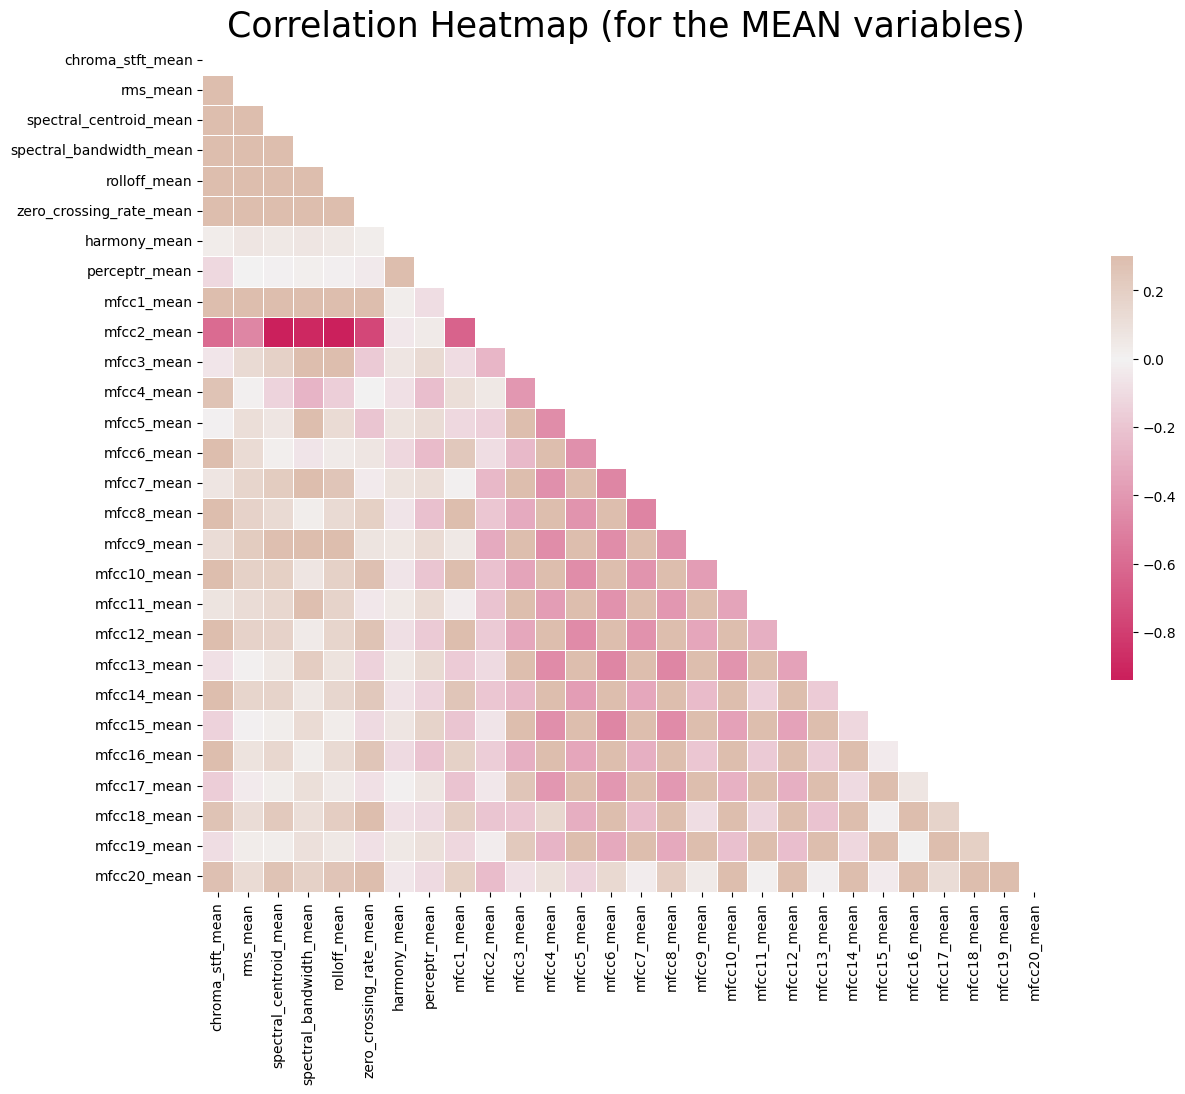

In [ ]:
# Computing the Correlation Matrix
spike_cols = [col for col in data.columns if 'mean' in col]
corr = data[spike_cols].corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=np.bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(16, 11));

# Generate a custom diverging colormap
cmap = sns.diverging_palette(0, 25, as_cmap=True, s = 90, l = 45, n = 5)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Correlation Heatmap (for the MEAN variables)', fontsize = 25)
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10);
plt.savefig("Corr Heatmap.jpg")

Box Plot for Genres Distributions

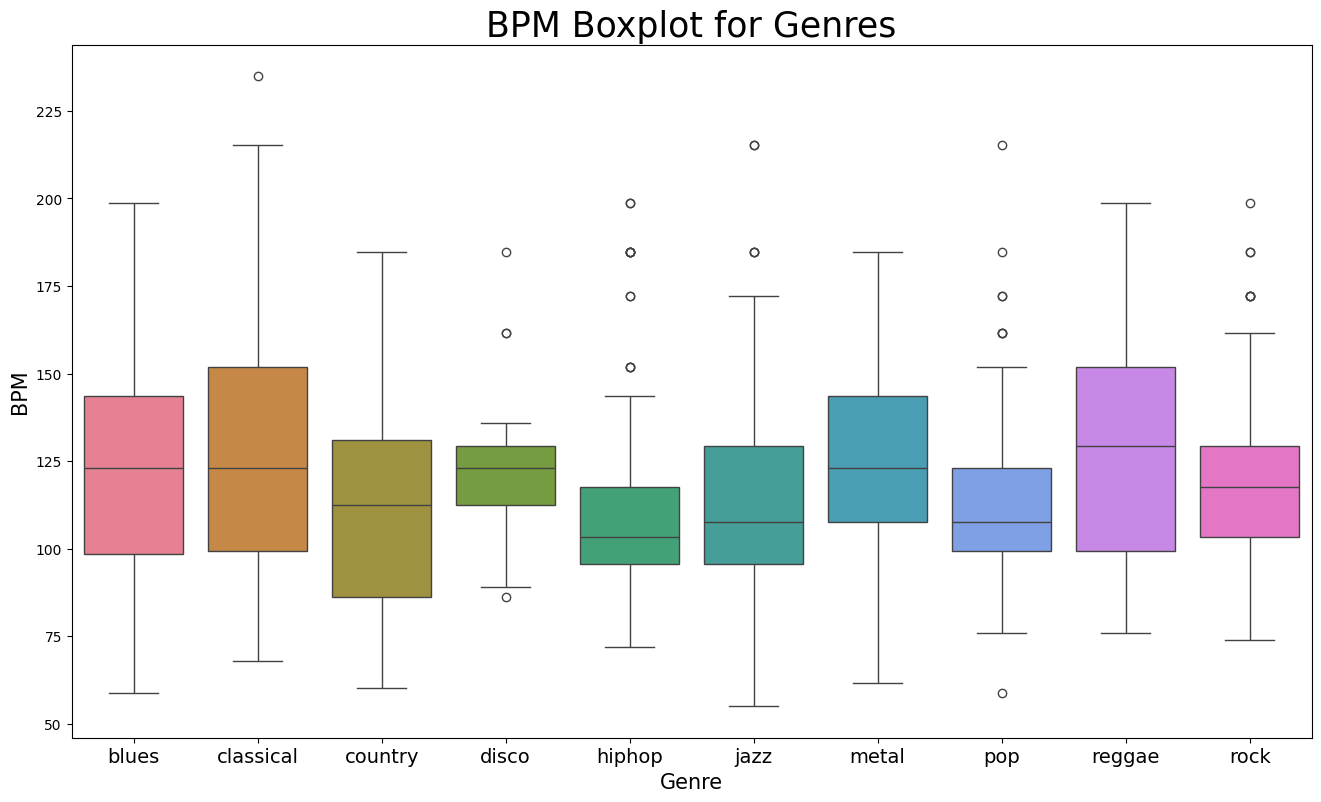

In [ ]:
x = data[["label", "tempo"]]

f, ax = plt.subplots(figsize=(16, 9));
sns.boxplot(x = "label", y = "tempo", data = x, palette = 'husl');

plt.title('BPM Boxplot for Genres', fontsize = 25)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 10);
plt.xlabel("Genre", fontsize = 15)
plt.ylabel("BPM", fontsize = 15)
plt.savefig("BPM Boxplot.jpg")

Principal Component Analysis - to visualize possible groups of genres¶

    Normalization
    PCA
    The Scatter Plot


In [ ]:
data.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [ ]:
from sklearn import preprocessing

y2 = data['filename']
data2 = data.iloc[0:, 1:]
y = data2['label']

# X is w/o columns filename & label 
X = data2.loc[:, data2.columns != 'label']

#### NORMALIZE X ####
cols = X.columns
min_max_scaler = preprocessing.MinMaxScaler()
np_scaled = min_max_scaler.fit_transform(X)
X = pd.DataFrame(np_scaled, columns = cols)


#### PCA 2/3 COMPONENTS ####
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
principalComponents = pca.fit_transform(X)
principalDf = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2', 'principal component 3'])

# concatenate with target label
finalDf = pd.concat([principalDf, y, y2], axis = 1)

pca.explained_variance_ratio_
finalDf.head()
# 44.93 variance explained

,principal component 1,principal component 2,principal component 3,label,filename
0,-0.394827,-0.115015,-0.099710,blues,blues.00000.wav
1,0.050684,-0.271071,0.427463,blues,blues.00001.wav
2,-0.479969,-0.223169,-0.014098,blues,blues.00002.wav
3,0.015376,-0.440066,0.017717,blues,blues.00003.wav
4,-0.162281,-0.508224,0.073907,blues,blues.00004.wav


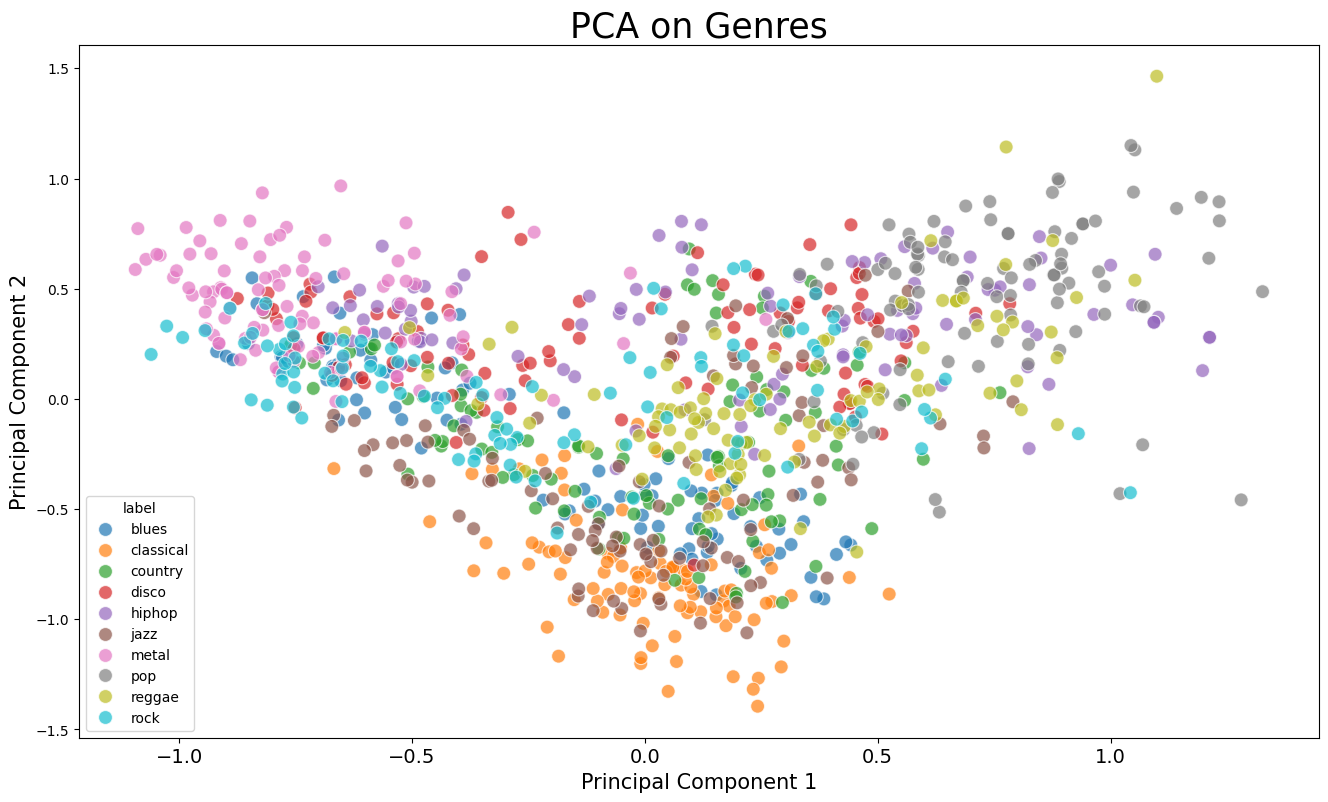

In [ ]:
plt.figure(figsize = (16, 9))
sns.scatterplot(x = "principal component 1", y = "principal component 2", 
                data = finalDf, hue = "label", alpha = 0.7,
               s = 100);

plt.title('PCA on Genres', fontsize = 25)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 10);
plt.xlabel("Principal Component 1", fontsize = 15)
plt.ylabel("Principal Component 2", fontsize = 15)
plt.savefig("PCA Scattert.jpg")

In [ ]:
import plotly.express as px
#plt.figure(figsize = (16, 9))
fig = px.scatter_3d(finalDf,
                   x = "principal component 1", y = "principal component 2", 
                   z = "principal component 3", color = "label", 
                   hover_data = ['filename']
                )
fig.show()
# plt.title('PCA on Genres', fontsize = 25)
# plt.xticks(fontsize = 14)
# plt.yticks(fontsize = 10);
# plt.xlabel("Principal Component 1", fontsize = 15)
# plt.ylabel("Principal Component 2", fontsize = 15)
# plt.savefig("PCA Scattert.jpg")

In [ ]:
from pathlib import Path

# BASE_DIR     = Path(__file__).resolve().parent.parent
# GENERAL_PATH = BASE_DIR / "gtzan-dataset-music-genre-classification" / "Data"
#PCA_PATH     = GENERAL_PATH / "PCA"
PCA_PATH = Path(r"C:\Users\Cyril\Documents\python\jedha\M11_projet\explo\music_genre_classification\gtzan-dataset-music-genre-classification\Data\PCA")
print(PCA_PATH)



C:\Users\Cyril\Documents\python\jedha\M11_projet\explo\music_genre_classification\gtzan-dataset-music-genre-classification\Data\PCA


In [ ]:
pca_file = Path(PCA_PATH / 'finalDf.csv' )
finalDf.to_csv(pca_file, index=False, encoding='utf-8-sig')
finalDf_reloaded = pd.read_csv(pca_file)

In [ ]:
finalDf

,principal component 1,principal component 2,principal component 3,label,filename
0,-0.394827,-0.115015,-0.099710,blues,blues.00000.wav
1,0.050684,-0.271071,0.427463,blues,blues.00001.wav
2,-0.479969,-0.223169,-0.014098,blues,blues.00002.wav
3,0.015376,-0.440066,0.017717,blues,blues.00003.wav
4,-0.162281,-0.508224,0.073907,blues,blues.00004.wav
...,...,...,...,...,...
995,-0.754686,-0.037197,0.011127,rock,rock.00095.wav
996,-0.810911,-0.028770,-0.156254,rock,rock.00096.wav
997,-0.845392,-0.004622,-0.110306,rock,rock.00097.wav
998,-0.235744,-0.372051,0.137526,rock,rock.00098.wav


### Machine Learning Classification

Using the features_3_sec.csv file, we can try to build a classifier that accurately predicts for any new audio file input it's genre.
Libraries

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier, XGBRFClassifier
from xgboost import plot_tree, plot_importance

from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE

### Reading in the Data

Now let's try to predict the Genre of the audio using Machine Learning techniques.

In [ ]:
data = pd.read_csv(f'{general_path}/features_3_sec.csv')
data = data.iloc[0:, 1:] 
data.head()

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,3714.560359,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,3869.682242,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,3997.639160,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,3568.300218,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,3469.992864,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


###Features and Target variable

    creates the target and feature variables
    normalizes the data


In [ ]:
y = data['label'] # genre variable.
X = data.loc[:, data.columns != 'label'] #select all columns but not the labels

#### NORMALIZE X ####

# Normalize so everything is on the same scale. 

cols = X.columns
min_max_scaler = preprocessing.MinMaxScaler()
np_scaled = min_max_scaler.fit_transform(X)

# new data frame with the new scaled data. 
X = pd.DataFrame(np_scaled, columns = cols)

Splitting the data into training and testing

    70% - 30% split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Creating a Predefined function to assess the accuracy of a model

    input is the model
    fits the model on the training dataset
    predicts on the testing features
    compares the predictions with the actuals


In [ ]:
def model_assess(model, title = "Default"):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    #print(confusion_matrix(y_test, preds))
    print('Accuracy', title, ':', round(accuracy_score(y_test, preds), 5), '\n')

#### Trying 10 different models to assess their performance¶

We tried 10 classification models, the best performing model was XGBooster.

In [ ]:
# Naive Bayes
nb = GaussianNB()
model_assess(nb, "Naive Bayes")

# Stochastic Gradient Descent
sgd = SGDClassifier(max_iter=5000, random_state=0)
model_assess(sgd, "Stochastic Gradient Descent")

# KNN
knn = KNeighborsClassifier(n_neighbors=19)
model_assess(knn, "KNN")

# Decission trees
tree = DecisionTreeClassifier()
model_assess(tree, "Decission trees")

# Random Forest
rforest = RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=0)
model_assess(rforest, "Random Forest")

# Support Vector Machine
svm = SVC(decision_function_shape="ovo")
model_assess(svm, "Support Vector Machine")


Accuracy Naive Bayes : 0.51952 

Accuracy Stochastic Gradient Descent : 0.65966 

Accuracy KNN : 0.80581 

Accuracy Decission trees : 0.64531 

Accuracy Random Forest : 0.81415 

Accuracy Support Vector Machine : 0.75409 



In [ ]:

# Logistic Regression
#lg = LogisticRegression(random_state=0, solver='lbfgs', multi_class='multinomial')
lg = LogisticRegression(random_state=0, solver='lbfgs', multi_class='auto')
model_assess(lg, "Logistic Regression")


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [ ]:

# Neural Nets
nn = MLPClassifier(solver='lbfgs', alpha=1e-5, hidden_layer_sizes=(5000, 10), random_state=1)
model_assess(nn, "Neural Nets")

# Cross Gradient Booster
xgb = XGBClassifier(n_estimators=1000, learning_rate=0.05)
model_assess(xgb, "Cross Gradient Booster")

# Cross Gradient Booster (Random Forest)
xgbrf = XGBRFClassifier(objective= 'multi:softmax')
model_assess(xgbrf, "Cross Gradient Booster (Random Forest)")

Accuracy Neural Nets : 0.67768 



ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4 5 6 7 8 9], got ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']

XGBoost is the winner - 90% accuracy¶

    create the final model
    compute confusion matrix
    Compute Feature Importance


In [ ]:
# Final model
xgb = XGBClassifier(n_estimators=1000, learning_rate=0.05)
xgb.fit(X_train, y_train)


preds = xgb.predict(X_test)

print('Accuracy', ':', round(accuracy_score(y_test, preds), 5), '\n')

# Confusion Matrix
confusion_matr = confusion_matrix(y_test, preds) #normalize = 'true'
plt.figure(figsize = (16, 9))
sns.heatmap(confusion_matr, cmap="Blues", annot=True, 
            xticklabels = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"],
           yticklabels=["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]);
plt.savefig("conf matrix")

### Feature Importance

In [ ]:
import eli5
from eli5.sklearn import PermutationImportance

perm = PermutationImportance(estimator=xgb, random_state=1)
perm.fit(X_test, y_test)

eli5.show_weights(estimator=perm, feature_names = X_test.columns.tolist())

## Recommender Systems

"Recomender" Systems enable us for any given vector to find the best similarity, ranked in descending order, from the bast match to the least best match.

For Audio files, this will be done through cosine_similarity library.

In [ ]:
# Libraries
import IPython.display as ipd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn import preprocessing

# Read data
data = pd.read_csv(f'{general_path}/features_30_sec.csv', index_col='filename')

# Extract labels
labels = data[['label']]

# Drop labels from original dataframe
data = data.drop(columns=['length','label'])
data.head()

# Scale the data
data_scaled=preprocessing.scale(data)
print('Scaled data type:', type(data_scaled))

#### Cosine similarity

Calculates the pairwise cosine similarity for each combination of songs in the data. This results in a 1000 x 1000 matrix (with redundancy in the information as item A similarity to item B == item B similarity to item A).

In [ ]:
# Cosine similarity
similarity = cosine_similarity(data_scaled)
print("Similarity shape:", similarity.shape)

# Convert into a dataframe and then set the row index and column names as labels
sim_df_labels = pd.DataFrame(similarity)
sim_df_names = sim_df_labels.set_index(labels.index)
sim_df_names.columns = labels.index

sim_df_names.head()

Song similarity scoring

find_similar_songs() - is a predefined function that takes the name of the song and returns top 5 best matches for that song.

In [ ]:
def find_similar_songs(name):
    # Find songs most similar to another song
    series = sim_df_names[name].sort_values(ascending = False)
    
    # Remove cosine similarity == 1 (songs will always have the best match with themselves)
    series = series.drop(name)
    
    # Display the 5 top matches 
    print("\n*******\nSimilar songs to ", name)
    print(series.head(5))